# Learning the moving boundary in the symmetric singular FBSDE

This notebook studies the symmetric two-particle problem from Jettkant and Søjmark and compares three numerical constructions.

1. Reference — an independent Monte Carlo first-exit calculation using the analytical singleton boundary. This is used only for evaluation.
2. Direct Deep BSDE — a deliberately simple application of the forward Deep BSDE idea shown in Andreas Søjmark's slides.
3. Cascade-aware method — learn the lower-level singleton field first, freeze it, use it to define the moving boundary, and only then learn the two-particle field.

The exact singleton formula is never used to train either learned-boundary method. It is used only for the reference, the oracle control, and post-training evaluation.

## Notebook structure

1. Numerical setup
2. Independent reference
3. Oracle exact-boundary control
4. Direct Deep BSDE application
5. Cascade-aware learned-boundary method
6. Independent comparison
7. Higher-dimensional extension
8. Saved outputs and interpretation

## 1 Numerical setup

In [1]:
from __future__ import annotations

import copy
import json
import math
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

RESULTS_DIR = Path.cwd() / "dissertation_moving_boundary_final_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Device", DEVICE)
if DEVICE.type == "cuda":
    print("GPU", torch.cuda.get_device_name(0))
print("Results directory", RESULTS_DIR.resolve())
print("Random seed", SEED)

Device cuda
GPU NVIDIA A100-SXM4-40GB
Results directory /content/dissertation_moving_boundary_final_results
Random seed 123


### 1.1 Configuration

In [2]:
@dataclass(frozen=True)
class OptimConfig:
    iterations: int = 15_000
    batch_size: int = 1_024
    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    gradient_clip: float = 10.0
    validation_every: int = 200
    display_every: int = 200
    naive_seed: int = 123


@dataclass(frozen=True)
class CascadeConfig:
    terminal_time: float = 1.0
    sigma: float = 1.0
    alpha: float = 1.0

    x_min: float = 1.0
    x_max: float = 4.0
    singleton_x_min: float = 2.001
    max_start_time: float = 0.95

    train_steps: int = 40
    width: int = 64
    depth: int = 3
    validation_size: int = 8_192

    reference_grid_size: int = 61
    reference_paths: int = 2_048
    reference_steps: int = 400
    reference_point_batch: int = 32

    model_plot_grid_size: int = 181
    diagnostic_paths: int = 20_000
    diagnostic_steps: int = 400

    geometry_times: tuple[float, ...] = (
        0.00, 0.20, 0.40, 0.60, 0.75, 0.90, 0.95, 1.00
    )
    comparison_times: tuple[float, ...] = (
        0.00, 0.50, 0.90, 0.95
    )


OPTIM = OptimConfig()
CASCADE = CascadeConfig()

FORCE_REFERENCE = False
FORCE_ORACLE = False
FORCE_NAIVE_GLOBAL = False
FORCE_SINGLETON = False
FORCE_CASCADE_LEVEL_TWO = False

configuration = {
    "seed": SEED,
    "optim": asdict(OPTIM),
    "cascade": asdict(CASCADE),
    "device": str(DEVICE),
    "torch": torch.__version__,
    "numpy": np.__version__,
    "python": sys.version,
    "platform": platform.platform(),
}
with (RESULTS_DIR / "configuration.json").open("w", encoding="utf-8") as file:
    json.dump(configuration, file, indent=2, sort_keys=True)

display(pd.DataFrame({
    "setting": [
        "training iterations for every learned model",
        "direct Deep BSDE seed",
        "batch size",
        "training time steps",
        "reference time steps",
        "reference paths per point",
        "reference heatmap times",
    ],
    "value": [
        OPTIM.iterations,
        OPTIM.naive_seed,
        OPTIM.batch_size,
        CASCADE.train_steps,
        CASCADE.reference_steps,
        CASCADE.reference_paths,
        len(CASCADE.geometry_times),
    ],
}))

,setting,value
0,training iterations for every learned model,15000
1,direct Deep BSDE seed,123
2,batch size,1024
3,training time steps,40
4,reference time steps,400
5,reference paths per point,2048
6,reference heatmap times,8


### 1.2 Randomness and utilities

In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int) -> torch.Generator:
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    return generator


def uniform(
    shape: tuple[int, ...],
    low: float,
    high: float,
    generator: torch.Generator,
) -> Tensor:
    return low + (high - low) * torch.rand(
        shape,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )


def tensor_to_numpy(value: Tensor) -> np.ndarray:
    return value.detach().cpu().numpy()


def normal_cdf(value: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(value / math.sqrt(2.0)))


def masked_mean(value: Tensor, mask: Tensor) -> Tensor:
    if bool(mask.any()):
        return value[mask].mean()
    return value.sum() * 0.0


def first_true_index(mask: Tensor) -> tuple[Tensor, Tensor]:
    if mask.ndim != 2:
        raise ValueError("mask must have shape (batch,time)")
    hit = mask.any(dim=1)
    index = mask.to(torch.int64).argmax(dim=1)
    final_index = mask.shape[1] - 1
    index = torch.where(hit, index, torch.full_like(index, final_index))
    return index, hit


def time_column(
    t: float | Tensor,
    batch_size: int,
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> Tensor:
    t_tensor = torch.as_tensor(t, device=device, dtype=dtype)
    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(batch_size)
    return t_tensor.reshape(batch_size, 1)


def save_figure(fig: plt.Figure, path: Path, *, show: bool = True) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

### 1.3 Neural architectures

In [4]:
class NormalisedMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        width: int,
        depth: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()
        if len(center) != input_dim or len(scale) != input_dim:
            raise ValueError("normalisation dimensions do not match input")

        self.register_buffer(
            "center",
            torch.tensor(center, dtype=DTYPE).reshape(1, -1),
        )
        self.register_buffer(
            "scale",
            torch.tensor(scale, dtype=DTYPE).reshape(1, -1),
        )

        layers: list[nn.Module] = []
        current = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(current, width))
            layers.append(nn.Softplus())
            current = width
        layers.append(nn.Linear(current, output_dim))
        self.network = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: Tensor) -> Tensor:
        normalised = (x - self.center) / self.scale
        return self.network(normalised)

    def zero_last_layer(self) -> None:
        final = next(
            module
            for module in reversed(self.network)
            if isinstance(module, nn.Linear)
        )
        nn.init.zeros_(final.weight)
        nn.init.zeros_(final.bias)


class BoundedSingletonFBSDE(nn.Module):
    # Stopped singleton approximation used by the proposed cascade.
    def __init__(
        self,
        *,
        x_min: float,
        x_max: float,
        width: int,
        depth: int,
    ) -> None:
        super().__init__()
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)
        center = (0.5, x_center)
        scale = (0.5, x_scale)

        self.value_net = NormalisedMLP(
            2, 1, width, depth, center, scale
        )
        self.z_net = NormalisedMLP(
            2, 1, width, depth, center, scale
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        x_flat = x.reshape(-1)
        t_col = time_column(
            t, x_flat.shape[0], device=x.device, dtype=x.dtype
        )
        raw = self.value_net(
            torch.cat((t_col, x_flat.unsqueeze(1)), dim=1)
        )[:, 0]
        return 1.0 + torch.sigmoid(raw)

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        x_flat = x.reshape(-1)
        t_col = time_column(
            t, x_flat.shape[0], device=x.device, dtype=x.dtype
        )
        return self.z_net(
            torch.cat((t_col, x_flat.unsqueeze(1)), dim=1)
        )[:, 0]


class SymmetricTwoParticleFBSDE(nn.Module):
    # Permutation-invariant scalar active-count field.
    def __init__(
        self,
        *,
        x_min: float,
        x_max: float,
        width: int,
        depth: int,
    ) -> None:
        super().__init__()
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)

        self.value_net = NormalisedMLP(
            3,
            1,
            width,
            depth,
            center=(0.5, x_center, 0.5 * x_scale**2),
            scale=(0.5, x_scale, 0.5 * x_scale**2),
        )
        self.z_component_net = NormalisedMLP(
            3,
            1,
            width,
            depth,
            center=(0.5, x_center, x_center),
            scale=(0.5, x_scale, x_scale),
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        t_col = time_column(t, x.shape[0], device=x.device, dtype=x.dtype)
        mean = x.mean(dim=1, keepdim=True)
        half_gap_squared = 0.25 * (x[:, 0:1] - x[:, 1:2]).square()
        return self.value_net(
            torch.cat((t_col, mean, half_gap_squared), dim=1)
        )[:, 0]

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        t_col = time_column(t, x.shape[0], device=x.device, dtype=x.dtype)
        z1 = self.z_component_net(
            torch.cat((t_col, x[:, 0:1], x[:, 1:2]), dim=1)
        )
        z2 = self.z_component_net(
            torch.cat((t_col, x[:, 1:2], x[:, 0:1]), dim=1)
        )
        return torch.cat((z1, z2), dim=1)

class NaiveGlobalFBSDE(nn.Module):
    """Direct vector-valued Deep BSDE approximation.

    V_theta takes (X_0, I_0) and returns the two initial backward values.
    W_theta takes (t_k, X_k, I_k) and returns the 2 x 2 martingale matrix.
    No range constraint, clipping, analytical boundary, or cascade information is imposed.
    """
    def __init__(
        self,
        *,
        x_min: float,
        x_max: float,
        width: int,
        depth: int,
    ) -> None:
        super().__init__()
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)

        self.value_net = NormalisedMLP(
            4,
            2,
            width,
            depth,
            center=(x_center, x_center, 0.5, 0.5),
            scale=(x_scale, x_scale, 0.5, 0.5),
        )
        self.z_net = NormalisedMLP(
            5,
            4,
            width,
            depth,
            center=(0.5, x_center, x_center, 0.5, 0.5),
            scale=(0.5, x_scale, x_scale, 0.5, 0.5),
        )

    def value(self, x: Tensor, alive: Tensor) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        if alive.shape != x.shape:
            raise ValueError("alive must have shape (batch,2)")
        features = torch.cat((x, alive), dim=1)
        return self.value_net(features)

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
        alive: Tensor,
    ) -> Tensor:
        if x.ndim != 2 or x.shape[1] != 2:
            raise ValueError("x must have shape (batch,2)")
        t_col = time_column(t, x.shape[0], device=x.device, dtype=x.dtype)
        features = torch.cat((t_col, x, alive), dim=1)
        return self.z_net(features).reshape(-1, 2, 2)

    def aggregate_value(self, x: Tensor) -> Tensor:
        alive = torch.ones_like(x)
        return self.value(x, alive).sum(dim=1)

### 1.4 Brownian simulation and Deep BSDE recursions

In [5]:
@dataclass
class BrownianBatch:
    start_time: Tensor
    times: Tensor
    x0: Tensor
    paths: Tensor
    increments: Tensor


def sample_brownian_batch(
    *,
    batch_size: int,
    dimension: int,
    steps: int,
    x_min: float,
    x_max: float,
    max_start_time: float,
    sigma: float,
    generator: torch.Generator,
    antithetic: bool,
) -> BrownianBatch:
    if antithetic and batch_size % 2 != 0:
        raise ValueError("antithetic batch size must be even")

    base_size = batch_size // 2 if antithetic else batch_size
    start_time = uniform((base_size,), 0.0, max_start_time, generator)
    x0 = uniform((base_size, dimension), x_min, x_max, generator)
    normals = torch.randn(
        base_size,
        steps,
        dimension,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

    if antithetic:
        start_time = torch.cat((start_time, start_time.clone()), dim=0)
        x0 = torch.cat((x0, x0.clone()), dim=0)
        normals = torch.cat((normals, -normals), dim=0)

    dt = (CASCADE.terminal_time - start_time) / steps
    increments = sigma * torch.sqrt(dt).view(-1, 1, 1) * normals
    fraction = torch.arange(
        steps + 1, device=DEVICE, dtype=DTYPE
    ).view(1, -1) / steps
    times = (
        start_time[:, None]
        + (CASCADE.terminal_time - start_time)[:, None] * fraction
    )

    zero = torch.zeros(
        batch_size, 1, dimension, device=DEVICE, dtype=DTYPE
    )
    paths = x0[:, None, :] + torch.cat(
        (zero, increments.cumsum(dim=1)), dim=1
    )
    return BrownianBatch(start_time, times, x0, paths, increments)


def forward_singleton(
    model: BoundedSingletonFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(batch.start_time, batch.x0[:, 0])
    for k in range(batch.increments.shape[1]):
        active = (stop_index > k).to(DTYPE)
        z = model.z(batch.times[:, k], batch.paths[:, k, 0])
        y = y + active * z * batch.increments[:, k, 0]
    return y


def forward_two_particle(
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(batch.start_time, batch.x0)
    for k in range(batch.increments.shape[1]):
        active = (stop_index > k).to(DTYPE)
        z = model.z(batch.times[:, k], batch.paths[:, k])
        y = y + active * (z * batch.increments[:, k]).sum(dim=1)
    return y

def _apply_naive_defaults(
    *,
    y: Tensor,
    x: Tensor,
    alive: Tensor,
    defaulted: Tensor,
    first_exit_index: Tensor,
    first_exit_hit: Tensor,
    grid_index: int,
) -> tuple[Tensor, Tensor, Tensor, Tensor]:
    """Detect defaults from the current raw Deep BSDE state.

    A default changes the active set, but its current Y value is not overwritten.
    The terminal loss must therefore learn the value 1 on defaulted paths rather
    than receiving that value for free.
    """
    threshold = CASCADE.alpha * y.sum(dim=1, keepdim=True)
    new_default = alive & (x <= threshold)
    path_has_new_default = new_default.any(dim=1)
    first_event = (~first_exit_hit) & path_has_new_default
    first_exit_index = torch.where(
        first_event,
        torch.full_like(first_exit_index, grid_index),
        first_exit_index,
    )
    first_exit_hit = first_exit_hit | path_has_new_default
    defaulted = defaulted | new_default
    alive = alive & (~new_default)
    return alive, defaulted, first_exit_index, first_exit_hit


def naive_global_rollout(
    model: NaiveGlobalFBSDE,
    batch: BrownianBatch,
    *,
    return_history: bool = False,
) -> dict[str, Tensor]:
    batch_size = batch.x0.shape[0]
    n_steps = batch.increments.shape[1]
    alive = torch.ones(
        batch_size, 2, device=DEVICE, dtype=torch.bool
    )
    defaulted = torch.zeros_like(alive)
    first_exit_index = torch.full(
        (batch_size,), n_steps, device=DEVICE, dtype=torch.long
    )
    first_exit_hit = torch.zeros(
        batch_size, device=DEVICE, dtype=torch.bool
    )

    # Slide-style initial condition Y_0 = V_theta(X_0, I_0).
    y = model.value(batch.x0, alive.to(DTYPE))

    y_history = [y.clone()] if return_history else []
    alive_history = [alive.clone()] if return_history else []

    for k in range(n_steps):
        current_x = batch.paths[:, k]
        current_t = batch.times[:, k]

        alive, defaulted, first_exit_index, first_exit_hit = (
            _apply_naive_defaults(
                y=y,
                x=current_x,
                alive=alive,
                defaulted=defaulted,
                first_exit_index=first_exit_index,
                first_exit_hit=first_exit_hit,
                grid_index=k,
            )
        )

        z = model.z(current_t, current_x, alive.to(DTYPE))
        martingale_increment = torch.einsum(
            "bij,bj->bi", z, batch.increments[:, k]
        )
        y_candidate = y + martingale_increment

        # Once a component defaults its diffusion is switched off.  Its value
        # is frozen at the learned hitting value; it is not hard-set to 1.
        y = torch.where(alive, y_candidate, y)

        if return_history:
            y_history.append(y.clone())
            alive_history.append(alive.clone())

    alive, defaulted, first_exit_index, first_exit_hit = (
        _apply_naive_defaults(
            y=y,
            x=batch.paths[:, -1],
            alive=alive,
            defaulted=defaulted,
            first_exit_index=first_exit_index,
            first_exit_hit=first_exit_hit,
            grid_index=n_steps,
        )
    )

    target = defaulted.to(DTYPE)
    result = {
        "terminal_y": y,
        "target": target,
        "defaulted": defaulted,
        "alive": alive,
        "first_exit_index": first_exit_index,
        "first_exit_hit": first_exit_hit,
    }
    if return_history:
        result["y_history"] = torch.stack(y_history, dim=1)
        result["alive_history"] = torch.stack(alive_history, dim=1)
    return result


def naive_global_loss(
    model: NaiveGlobalFBSDE,
    batch: BrownianBatch,
) -> Tensor:
    rollout = naive_global_rollout(model, batch)
    return (rollout["terminal_y"] - rollout["target"]).square().mean()


@torch.no_grad()
def naive_rollout_range_diagnostics(
    model: NaiveGlobalFBSDE,
    batch: BrownianBatch,
) -> dict[str, float]:
    rollout = naive_global_rollout(model, batch, return_history=True)
    history = rollout["y_history"]
    active_history = rollout["alive_history"]
    active_values = history[active_history]

    if active_values.numel() == 0:
        return {
            "path_range_violation_rate": 0.0,
            "path_value_minimum": math.nan,
            "path_value_maximum": math.nan,
        }

    violation = (active_values < 0.0) | (active_values > 1.0)
    return {
        "path_range_violation_rate": float(
            violation.to(DTYPE).mean().cpu()
        ),
        "path_value_minimum": float(active_values.min().cpu()),
        "path_value_maximum": float(active_values.max().cpu()),
    }

### 1.5 Training and plotting utilities

In [6]:
@dataclass
class TrainingResult:
    best_iteration: int
    best_validation_loss: float
    runtime_seconds: float
    loaded_from_cache: bool
    history: pd.DataFrame


def plot_training_history(
    result: TrainingResult,
    title: str,
    path: Path,
) -> None:
    if result.history.empty:
        return

    fig, ax = plt.subplots(figsize=(7.0, 4.3), constrained_layout=True)
    floor = np.finfo(float).tiny

    train = result.history.dropna(subset=["training_loss"])
    validation = result.history.dropna(subset=["validation_loss"])

    ax.semilogy(
        train["iteration"],
        np.maximum(train["training_loss"], floor),
        linewidth=0.9,
        label="training",
    )
    ax.semilogy(
        validation["iteration"],
        np.maximum(validation["validation_loss"], floor),
        marker="o",
        markersize=2.5,
        linewidth=0.9,
        label="validation",
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean squared objective")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    save_figure(fig, path, show=False)


def load_or_train(
    *,
    model: nn.Module,
    name: str,
    output_dir: Path,
    train_objective: Callable[[nn.Module], Tensor],
    validation_objective: Callable[[nn.Module], Tensor],
    iterations: int,
    batch_size: int,
    force: bool,
    learning_rate: float = 1.0e-3,
    validation_every: int = 200,
    display_every: int = 200,
    scheduler_step: int = 1_000,
    scheduler_gamma: float = 0.95,
    gradient_clip: float = 10.0,
) -> TrainingResult:
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = output_dir / f"{name}_best.pt"
    history_path = output_dir / f"{name}_history.csv"

    if checkpoint_path.exists() and not force:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state"])
        history = (
            pd.read_csv(history_path)
            if history_path.exists()
            else pd.DataFrame()
        )
        return TrainingResult(
            best_iteration=int(checkpoint["best_iteration"]),
            best_validation_loss=float(checkpoint["best_validation_loss"]),
            runtime_seconds=float(checkpoint.get("runtime_seconds", 0.0)),
            loaded_from_cache=True,
            history=history,
        )

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step,
        gamma=scheduler_gamma,
    )

    best_loss = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    records: list[dict[str, float]] = []
    start = time.time()

    for iteration in range(1, iterations + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        loss = train_objective(model)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"non-finite loss in {name}")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()
        scheduler.step()

        validation_value = math.nan
        if iteration % validation_every == 0 or iteration == iterations:
            model.eval()
            with torch.no_grad():
                validation_value = float(validation_objective(model).item())
            if validation_value < best_loss:
                best_loss = validation_value
                best_iteration = iteration
                best_state = copy.deepcopy(model.state_dict())

        if iteration % display_every == 0 or iteration == iterations:
            train_value = float(loss.item())
            records.append({
                "iteration": iteration,
                "training_loss": train_value,
                "validation_loss": validation_value,
            })
            print(
                f"{name:34s} iteration {iteration:5d} "
                f"train {train_value:.6e} val {validation_value:.6e}"
            )

    runtime = time.time() - start
    model.load_state_dict(best_state)

    history = pd.DataFrame(records)
    history.to_csv(history_path, index=False)
    torch.save(
        {
            "model_state": best_state,
            "best_iteration": best_iteration,
            "best_validation_loss": best_loss,
            "runtime_seconds": runtime,
            "batch_size": batch_size,
        },
        checkpoint_path,
    )

    return TrainingResult(
        best_iteration=best_iteration,
        best_validation_loss=best_loss,
        runtime_seconds=runtime,
        loaded_from_cache=False,
        history=history,
    )

EXACT_BOUNDARY_STYLE = {
    "color": "red",
    "linestyle": (0, (10, 5)),
    "linewidth": 1.25,
    "alpha": 0.95,
}
LEARNED_BOUNDARY_STYLE = {
    "color": "cyan",
    "linestyle": "-",
    "linewidth": 1.05,
    "alpha": 0.95,
}


def plot_exact_boundary(
    ax: plt.Axes,
    time_value: float,
    *,
    label: str | None = None,
    zorder: float = 5.0,
) -> None:
    for curve_index, (x_curve, y_curve) in enumerate(
        exact_boundary_curves(time_value)
    ):
        ax.plot(
            x_curve,
            y_curve,
            **EXACT_BOUNDARY_STYLE,
            zorder=zorder,
            label=label if curve_index == 0 else None,
        )


def plot_graph_boundary(
    ax: plt.Axes,
    time_value: float,
    boundary_function: Callable[[float, Tensor], Tensor],
    *,
    color: str = "cyan",
    linestyle: str | tuple = "-",
    linewidth: float = 1.05,
    label: str | None = None,
    zorder: float = 6.0,
) -> None:
    survivor = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = boundary_function(time_value, survivor)
    ax.plot(
        tensor_to_numpy(boundary),
        tensor_to_numpy(survivor),
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=zorder,
        label=label,
    )
    ax.plot(
        tensor_to_numpy(survivor),
        tensor_to_numpy(boundary),
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=zorder,
    )


def plot_four_heatmaps(
    *,
    surfaces: dict[float, tuple[np.ndarray, np.ndarray]],
    title: str,
    output_path: Path,
    boundary_plotter: Callable[[plt.Axes, float], None],
    value_min: float = 0.0,
    value_max: float = 2.0,
) -> None:
    fig, axes = plt.subplots(
        2, 2, figsize=(10.8, 9.0), constrained_layout=True
    )
    image = None

    for ax, time_value in zip(axes.flat, CASCADE.comparison_times):
        axis, field = surfaces[float(time_value)]
        image = ax.imshow(
            field.T,
            origin="lower",
            extent=[axis[0], axis[-1], axis[0], axis[-1]],
            aspect="equal",
            interpolation="bilinear",
            cmap="viridis",
            vmin=value_min,
            vmax=value_max,
        )
        boundary_plotter(ax, float(time_value))
        ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
        ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
        ax.set_aspect("equal")
        ax.set_xlabel("x₁")
        ax.set_ylabel("x₂")
        ax.set_title(f"t = {time_value:.2f}")

    if image is None:
        raise RuntimeError("No heatmap was created.")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    if handles:
        axes.flat[0].legend(fontsize=8, loc="upper right")
    colorbar = fig.colorbar(image, ax=axes, shrink=0.84)
    colorbar.set_label("Value")
    fig.suptitle(title)
    save_figure(fig, output_path)

## 2 Independent reference

For the two-particle symmetric case with alpha equal to one, the one-particle problem has a fixed threshold at 2 and an analytical singleton value. When two particles remain, the smaller state is compared with the singleton value evaluated at the larger state. This produces the moving two-particle boundary.

The analytical singleton field is used here only to build an independent first-exit Monte Carlo reference and to draw the exact boundary. The eight heatmaps below are the main geometry figure for the notebook.

In [7]:
def exact_singleton_value(
    t: float | Tensor,
    x: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    t_tensor = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_tensor, x_tensor = torch.broadcast_tensors(t_tensor, x)

    remaining = config.terminal_time - t_tensor
    terminal = torch.where(
        x_tensor <= 2.0 * config.alpha,
        torch.full_like(x_tensor, 2.0),
        torch.full_like(x_tensor, 1.0),
    )

    safe_remaining = remaining.clamp_min(torch.finfo(x.dtype).eps)
    argument = torch.minimum(
        (2.0 * config.alpha - x_tensor)
        / (config.sigma * torch.sqrt(safe_remaining)),
        torch.zeros_like(x_tensor),
    )
    preterminal = 1.0 + 2.0 * normal_cdf(argument)
    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )


def exact_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    return config.alpha * exact_singleton_value(t, survivor, config)


def exact_terminal_continuation_mask(
    points: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    return (
        (smaller > config.alpha)
        & (larger > 2.0 * config.alpha)
    )


def exact_continuation_mask(
    t: float | Tensor,
    points: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    t_tensor = torch.as_tensor(
        t, device=points.device, dtype=points.dtype
    )
    if (
        t_tensor.ndim == 0
        and abs(float(t_tensor.item()) - config.terminal_time)
        <= 1.0e-12
    ):
        return exact_terminal_continuation_mask(points, config)

    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(points.shape[0])

    return smaller > exact_boundary_value(t_tensor, larger, config)


def exact_boundary_curves(
    t: float,
    config: CascadeConfig = CASCADE,
) -> list[tuple[np.ndarray, np.ndarray]]:
    if abs(t - config.terminal_time) <= 1.0e-12:
        low = np.linspace(config.x_min, 2.0 * config.alpha, 500)
        high = np.linspace(2.0 * config.alpha, config.x_max, 500)
        return [
            (np.full_like(low, 2.0 * config.alpha), low),
            (low, np.full_like(low, 2.0 * config.alpha)),
            (np.full_like(high, config.alpha), high),
            (high, np.full_like(high, config.alpha)),
        ]

    survivor = torch.linspace(
        config.x_min,
        config.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = exact_boundary_value(t, survivor, config)
    return [
        (tensor_to_numpy(boundary), tensor_to_numpy(survivor)),
        (tensor_to_numpy(survivor), tensor_to_numpy(boundary)),
    ]


r_left = torch.linspace(
    1.0, 2.0, 101, device=DEVICE, dtype=DTYPE
)
r_right = torch.linspace(
    2.001, 4.0, 201, device=DEVICE, dtype=DTYPE
)

for t_value in CASCADE.geometry_times:
    if t_value < 1.0:
        torch.testing.assert_close(
            exact_boundary_value(t_value, r_left),
            torch.full_like(r_left, 2.0),
            atol=2.0e-6,
            rtol=0.0,
        )

torch.testing.assert_close(
    exact_boundary_value(1.0, r_right),
    torch.ones_like(r_right),
    atol=2.0e-6,
    rtol=0.0,
)
print("Exact singleton and boundary checks passed")

Exact singleton and boundary checks passed


In [8]:
@torch.no_grad()
def reference_payoff_chunk(
    *,
    start_time: float,
    points: Tensor,
    increments: Tensor,
    config: CascadeConfig = CASCADE,
) -> Tensor:
    n_points = points.shape[0]
    n_paths = increments.shape[0]
    n_steps = increments.shape[1]
    dt = (config.terminal_time - start_time) / n_steps

    x = points[:, None, :].expand(n_points, n_paths, 2).clone()
    active = torch.ones(
        n_points, n_paths, device=DEVICE, dtype=torch.bool
    )
    payoff = torch.zeros(
        n_points, n_paths, device=DEVICE, dtype=DTYPE
    )

    for k in range(n_steps + 1):
        current_time = start_time + k * dt
        smaller = x.min(dim=2).values
        larger = x.max(dim=2).values
        threshold = exact_boundary_value(current_time, larger, config)
        new_exit = active & (smaller <= threshold)

        if bool(new_exit.any()):
            payoff[new_exit] = exact_singleton_value(
                current_time, larger[new_exit], config
            )
            active[new_exit] = False

        if k < n_steps:
            x = x + increments[:, k][None, :, :]

    return payoff


@torch.no_grad()
def compute_reference_surface(
    start_time: float,
    config: CascadeConfig = CASCADE,
) -> dict[str, Tensor]:
    axis = torch.linspace(
        config.x_min,
        config.x_max,
        config.reference_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

    inside = exact_continuation_mask(start_time, points, config)
    field = exact_singleton_value(
        start_time, points.max(dim=1).values, config
    )
    standard_error = torch.zeros_like(field)

    if abs(start_time - config.terminal_time) <= 1.0e-12:
        field[inside] = 0.0
        return {
            "axis": axis.cpu(),
            "points": points.cpu(),
            "inside": inside.cpu(),
            "field": field.cpu(),
            "standard_error": standard_error.cpu(),
        }

    inside_points = points[inside]
    if config.reference_paths % 2 != 0:
        raise ValueError("reference_paths must be even for antithetic sampling")
    half_paths = config.reference_paths // 2
    generator = make_generator(
        SEED + 10_000 + int(1_000 * start_time)
    )
    half_normals = torch.randn(
        half_paths,
        config.reference_steps,
        2,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    normals = torch.cat((half_normals, -half_normals), dim=0)
    dt = (config.terminal_time - start_time) / config.reference_steps
    increments = config.sigma * math.sqrt(dt) * normals

    estimates: list[Tensor] = []
    errors: list[Tensor] = []

    for start in range(
        0,
        inside_points.shape[0],
        config.reference_point_batch,
    ):
        chunk = inside_points[
            start : start + config.reference_point_batch
        ]
        samples = reference_payoff_chunk(
            start_time=start_time,
            points=chunk,
            increments=increments,
            config=config,
        )
        pair_means = 0.5 * (
            samples[:, :half_paths] + samples[:, half_paths:]
        )
        estimates.append(pair_means.mean(dim=1))
        errors.append(
            pair_means.std(dim=1, unbiased=True)
            / math.sqrt(half_paths)
        )

    if estimates:
        field[inside] = torch.cat(estimates)
        standard_error[inside] = torch.cat(errors)

    return {
        "axis": axis.cpu(),
        "points": points.cpu(),
        "inside": inside.cpu(),
        "field": field.cpu(),
        "standard_error": standard_error.cpu(),
    }


def compute_or_load_references(
    config: CascadeConfig = CASCADE,
) -> dict[float, dict[str, Tensor]]:
    output_dir = RESULTS_DIR / "01_reference"
    output_dir.mkdir(parents=True, exist_ok=True)
    cache = output_dir / "reference_surfaces.pt"

    required_times = tuple(
        sorted(set(config.geometry_times + config.comparison_times))
    )

    if cache.exists() and not FORCE_REFERENCE:
        references = torch.load(cache, map_location="cpu")
        if all(float(t_value) in references for t_value in required_times):
            print("Loaded independent reference surfaces")
            return references

    references: dict[float, dict[str, Tensor]] = {}
    for t_value in required_times:
        print(f"Computing independent reference at t={t_value:.2f}")
        references[float(t_value)] = compute_reference_surface(
            float(t_value), config
        )

    torch.save(references, cache)
    return references


reference_surfaces = compute_or_load_references()

Computing independent reference at t=0.00
Computing independent reference at t=0.20
Computing independent reference at t=0.40
Computing independent reference at t=0.50
Computing independent reference at t=0.60
Computing independent reference at t=0.75
Computing independent reference at t=0.90
Computing independent reference at t=0.95
Computing independent reference at t=1.00


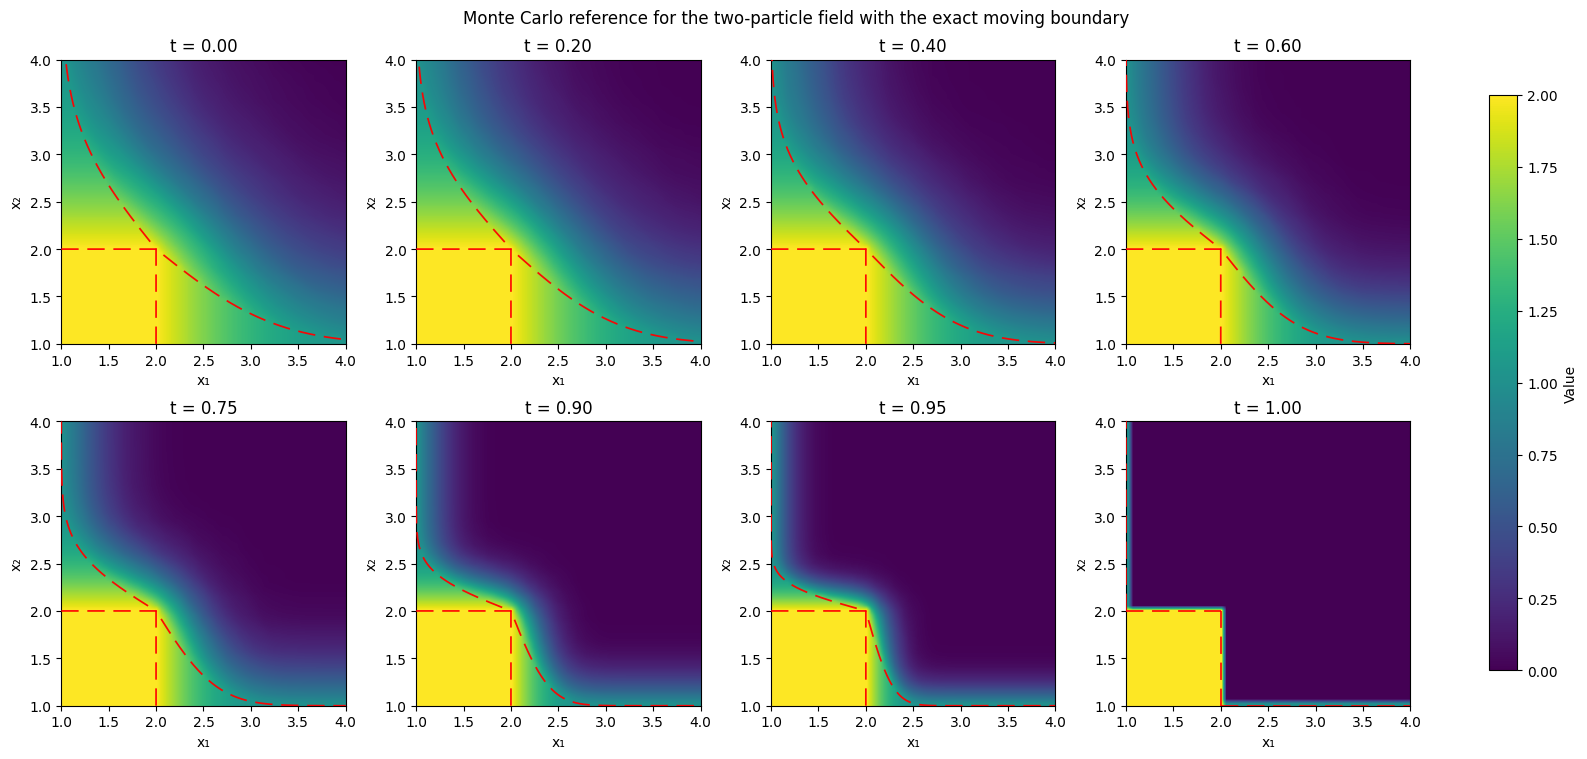

,time,Mean Monte Carlo SE,Maximum Monte Carlo SE
0,0.00,0.009544,0.013396
1,0.20,0.008908,0.013642
2,0.40,0.008089,0.014167
3,0.60,0.006883,0.014425
4,0.75,0.005654,0.015025
5,0.90,0.003772,0.015676
6,0.95,0.002866,0.015938
7,1.00,0.000000,0.000000


In [9]:
reference_dir = RESULTS_DIR / "01_reference"

fig, axes = plt.subplots(
    2, 4, figsize=(15.8, 7.5), constrained_layout=True
)
image = None

for ax, t_value in zip(axes.flat, CASCADE.geometry_times):
    reference = reference_surfaces[float(t_value)]
    axis_np = tensor_to_numpy(reference["axis"])
    field = tensor_to_numpy(reference["field"]).reshape(
        CASCADE.reference_grid_size,
        CASCADE.reference_grid_size,
    )

    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]],
        aspect="equal",
        interpolation="bilinear",
        cmap="viridis",
        vmin=0.0,
        vmax=2.0,
    )
    plot_exact_boundary(ax, float(t_value))
    ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
    ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"t = {t_value:.2f}")

if image is None:
    raise RuntimeError("Reference figure has no panels.")

colorbar = fig.colorbar(image, ax=axes, shrink=0.86)
colorbar.set_label("Value")
fig.suptitle(
    "Monte Carlo reference for the two-particle field with the exact moving boundary"
)
save_figure(
    fig,
    reference_dir / "reference_field_eight_times.pdf",
)

reference_uncertainty_rows = []
for t_value in CASCADE.geometry_times:
    reference = reference_surfaces[float(t_value)]
    inside = reference["inside"]
    standard_error = reference["standard_error"]
    inside_se = standard_error[inside]
    reference_uncertainty_rows.append({
        "time": float(t_value),
        "Mean Monte Carlo SE": float(inside_se.mean()) if inside_se.numel() else 0.0,
        "Maximum Monte Carlo SE": float(inside_se.max()) if inside_se.numel() else 0.0,
    })

reference_uncertainty = pd.DataFrame(reference_uncertainty_rows)
reference_uncertainty.to_csv(
    reference_dir / "reference_monte_carlo_uncertainty.csv", index=False
)
display(reference_uncertainty.round(6))


### 2.1 Stopped objective used by the oracle and cascade-aware methods

For a prescribed boundary, each simulated two-particle path is stopped at its first exit. If an exit occurs, the lower-level field supplies the target value. If no exit occurs before the terminal time, the terminal continuation value is used.

In [10]:
def n2_stop_target(
    batch: BrownianBatch,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    lower_value_provider: Callable[[Tensor, Tensor], Tensor],
    *,
    no_exit_value: float,
) -> tuple[Tensor, Tensor, Tensor]:
    smaller = batch.paths.min(dim=2).values
    larger = batch.paths.max(dim=2).values

    thresholds = boundary_provider(batch.times, larger)
    lower_values = lower_value_provider(batch.times, larger)

    breach = smaller <= thresholds
    stop_index, hit = first_true_index(breach)

    gather_index = stop_index.unsqueeze(1)
    stopped_lower_value = lower_values.gather(
        1, gather_index
    ).squeeze(1)

    target = torch.where(
        hit,
        stopped_lower_value,
        torch.full_like(stopped_lower_value, no_exit_value),
    )
    return stop_index, target, hit


def n2_loss(
    *,
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    lower_value_provider: Callable[[Tensor, Tensor], Tensor],
    terminal_value: float,
    pasting_time: Tensor,
    survivor: Tensor,
    terminal_points: Tensor,
    terminal_mask_function: Callable[[Tensor], Tensor],
) -> tuple[Tensor, dict[str, Tensor]]:
    with torch.no_grad():
        stop_index, target, _ = n2_stop_target(
            batch,
            boundary_provider,
            lower_value_provider,
            no_exit_value=terminal_value,
        )

    stopped_y = forward_two_particle(model, batch, stop_index)
    path_loss = (stopped_y - target).square().mean()

    with torch.no_grad():
        threshold = boundary_provider(pasting_time, survivor)
        lower_value = lower_value_provider(pasting_time, survivor)

    point_one = torch.stack((threshold, survivor), dim=1)
    point_two = torch.stack((survivor, threshold), dim=1)
    pasting_loss = 0.5 * (
        (
            model.value(pasting_time, point_one)
            - lower_value
        ).square().mean()
        +
        (
            model.value(pasting_time, point_two)
            - lower_value
        ).square().mean()
    )

    with torch.no_grad():
        terminal_inside = terminal_mask_function(terminal_points)
    terminal_prediction = model.value(
        CASCADE.terminal_time, terminal_points
    )
    terminal_loss = masked_mean(
        (terminal_prediction - terminal_value).square(),
        terminal_inside,
    )

    total = path_loss + pasting_loss + terminal_loss
    return total, {
        "path": path_loss,
        "pasting": pasting_loss,
        "terminal": terminal_loss,
    }


def sample_n2_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
) -> tuple[BrownianBatch, Tensor, Tensor, Tensor]:
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=2,
        steps=CASCADE.train_steps,
        x_min=CASCADE.x_min,
        x_max=CASCADE.x_max,
        max_start_time=CASCADE.max_start_time,
        sigma=CASCADE.sigma,
        generator=generator,
        antithetic=antithetic,
    )
    pasting_time = uniform(
        (batch_size,), 0.0, CASCADE.max_start_time, generator
    )
    survivor = uniform(
        (batch_size,), 2.001, CASCADE.x_max, generator
    )
    terminal_points = uniform(
        (batch_size, 2), CASCADE.x_min, CASCADE.x_max, generator
    )
    return batch, pasting_time, survivor, terminal_points


@torch.no_grad()
def completed_n2_value(
    *,
    model: SymmetricTwoParticleFBSDE,
    t: float | Tensor,
    points: Tensor,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    lower_value_provider: Callable[[Tensor, Tensor], Tensor],
    terminal_value: float,
) -> Tensor:
    t_tensor = torch.as_tensor(
        t, device=points.device, dtype=points.dtype
    )
    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(points.shape[0])

    raw = model.value(t_tensor, points)
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    threshold = boundary_provider(t_tensor, larger)
    lower = lower_value_provider(t_tensor, larger)
    inside = smaller > threshold

    terminal_mask = (
        torch.abs(t_tensor - CASCADE.terminal_time)
        <= 1.0e-12
    )
    raw = torch.where(
        terminal_mask,
        torch.full_like(raw, terminal_value),
        raw,
    )
    return torch.where(inside, raw, lower)


@torch.no_grad()
def model_surface(
    *,
    model: SymmetricTwoParticleFBSDE,
    time_value: float,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    lower_value_provider: Callable[[Tensor, Tensor], Tensor],
    terminal_value: float,
) -> tuple[np.ndarray, np.ndarray]:
    axis = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        CASCADE.model_plot_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

    field = completed_n2_value(
        model=model,
        t=time_value,
        points=points,
        boundary_provider=boundary_provider,
        lower_value_provider=lower_value_provider,
        terminal_value=terminal_value,
    ).reshape(
        CASCADE.model_plot_grid_size,
        CASCADE.model_plot_grid_size,
    )
    return tensor_to_numpy(axis), tensor_to_numpy(field)

## 3 Oracle exact-boundary control

The oracle experiment is a control. It supplies the analytical singleton field, so the exact moving boundary and exact exit payoff are known. Only the level-two neural field is trained. This separates ordinary level-two approximation error from boundary-learning error.

In [11]:
oracle_dir = RESULTS_DIR / "02_oracle"
seed_everything(SEED + 200)

oracle_model = SymmetricTwoParticleFBSDE(
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

exact_boundary_provider = (
    lambda t, r: exact_boundary_value(t, r)
)
exact_lower_value_provider = (
    lambda t, r: exact_singleton_value(t, r)
)

oracle_train_generator = make_generator(SEED + 201)
oracle_validation_generator = make_generator(SEED + 202)
oracle_validation_data = sample_n2_training_data(
    batch_size=CASCADE.validation_size,
    generator=oracle_validation_generator,
    antithetic=False,
)


def oracle_train_objective(model: nn.Module) -> Tensor:
    data = sample_n2_training_data(
        batch_size=OPTIM.batch_size,
        generator=oracle_train_generator,
        antithetic=True,
    )
    total, _ = n2_loss(
        model=model,
        batch=data[0],
        boundary_provider=exact_boundary_provider,
        lower_value_provider=exact_lower_value_provider,
        terminal_value=0.0,
        pasting_time=data[1],
        survivor=data[2],
        terminal_points=data[3],
        terminal_mask_function=exact_terminal_continuation_mask,
    )
    return total


def oracle_validation_objective(model: nn.Module) -> Tensor:
    total, _ = n2_loss(
        model=model,
        batch=oracle_validation_data[0],
        boundary_provider=exact_boundary_provider,
        lower_value_provider=exact_lower_value_provider,
        terminal_value=0.0,
        pasting_time=oracle_validation_data[1],
        survivor=oracle_validation_data[2],
        terminal_points=oracle_validation_data[3],
        terminal_mask_function=exact_terminal_continuation_mask,
    )
    return total


oracle_training = load_or_train(
    model=oracle_model,
    name="oracle_exact_boundary",
    output_dir=oracle_dir,
    train_objective=oracle_train_objective,
    validation_objective=oracle_validation_objective,
    iterations=OPTIM.iterations,
    batch_size=OPTIM.batch_size,
    force=FORCE_ORACLE,
    learning_rate=OPTIM.learning_rate,
    validation_every=OPTIM.validation_every,
    display_every=OPTIM.display_every,
    scheduler_step=OPTIM.scheduler_step,
    scheduler_gamma=OPTIM.scheduler_gamma,
    gradient_clip=OPTIM.gradient_clip,
)
oracle_model.eval()

plot_training_history(
    oracle_training,
    "Oracle exact-boundary training",
    oracle_dir / "training_history.pdf",
)

display(pd.DataFrame({
    "diagnostic": [
        "Best iteration",
        "Best validation loss",
        "Runtime in minutes",
    ],
    "value": [
        oracle_training.best_iteration,
        oracle_training.best_validation_loss,
        oracle_training.runtime_seconds / 60.0,
    ],
}))

oracle_exact_boundary              iteration   200 train 4.809514e-01 val 4.860149e-01
oracle_exact_boundary              iteration   400 train 4.680241e-01 val 4.410747e-01
oracle_exact_boundary              iteration   600 train 3.649977e-01 val 3.940536e-01
oracle_exact_boundary              iteration   800 train 2.812978e-01 val 2.807822e-01
oracle_exact_boundary              iteration  1000 train 2.651366e-01 val 2.836628e-01
oracle_exact_boundary              iteration  1200 train 2.452375e-01 val 2.436039e-01
oracle_exact_boundary              iteration  1400 train 2.258342e-01 val 2.310944e-01
oracle_exact_boundary              iteration  1600 train 2.110668e-01 val 2.073539e-01
oracle_exact_boundary              iteration  1800 train 1.552745e-01 val 1.835678e-01
oracle_exact_boundary              iteration  2000 train 1.541496e-01 val 1.543375e-01
oracle_exact_boundary              iteration  2200 train 1.445000e-01 val 1.387252e-01
oracle_exact_boundary              iteratio

,diagnostic,value
0,Best iteration,14800.000000
1,Best validation loss,0.020813
2,Runtime in minutes,20.606154


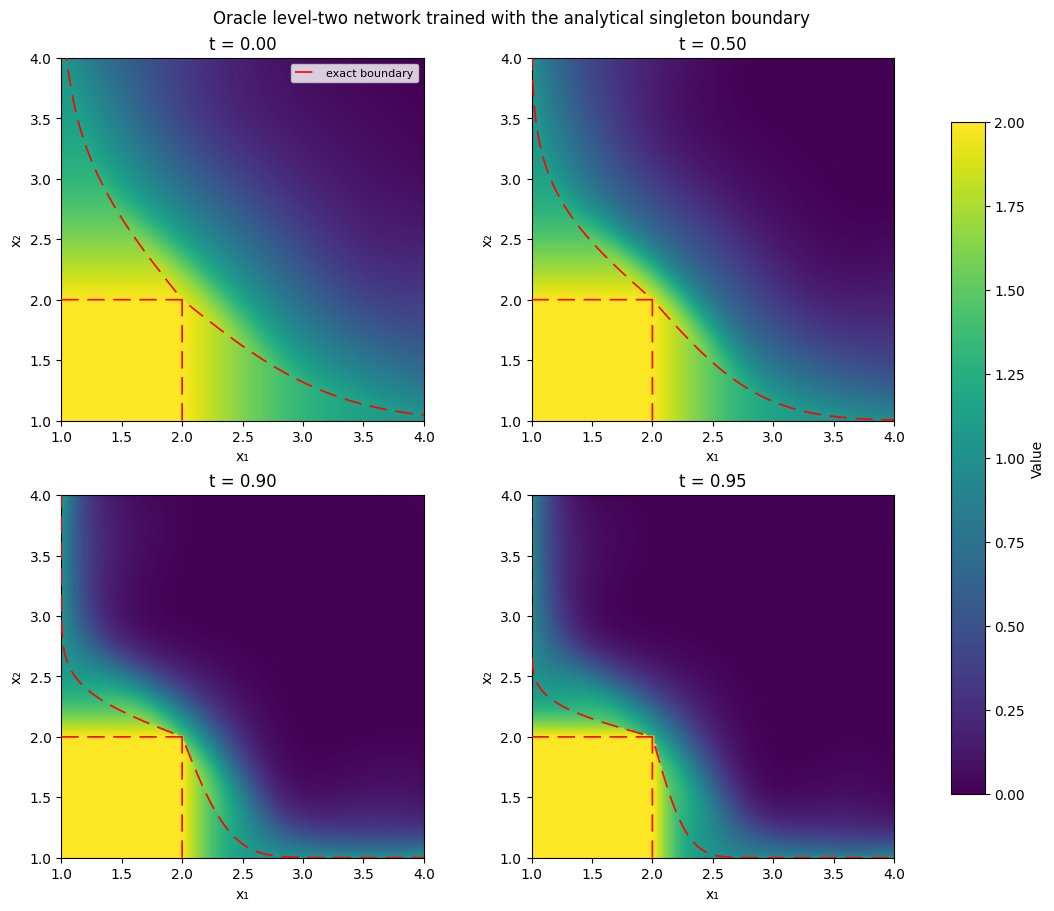

In [12]:
oracle_surfaces = {
    float(t_value): model_surface(
        model=oracle_model,
        time_value=float(t_value),
        boundary_provider=exact_boundary_provider,
        lower_value_provider=exact_lower_value_provider,
        terminal_value=0.0,
    )
    for t_value in CASCADE.comparison_times
}


def oracle_boundary_plotter(
    ax: plt.Axes, t_value: float
) -> None:
    plot_exact_boundary(
        ax,
        t_value,
        label="exact boundary",
    )


plot_four_heatmaps(
    surfaces=oracle_surfaces,
    title="Oracle level-two network trained with the analytical singleton boundary",
    output_path=oracle_dir / "oracle_field_four_times.pdf",
    boundary_plotter=oracle_boundary_plotter,
)

## 4 Direct Deep BSDE application

This is the deliberately simple baseline based on the Deep BSDE recursion shown in Andreas Søjmark's slides, specialised to two particles.

At time zero, a value network predicts the two backward values. At every time step, a second network predicts the two-by-two martingale coefficient and the backward values are advanced with the Brownian increment.

The current raw sum of the two backward values is used as the endogenous default boundary. If a particle crosses that boundary, it is marked as defaulted and its backward component is frozen from that point onward. It is not hard-set to one. The final loss is the mean squared error between the two terminal backward values and the two simulated default indicators.

No analytical singleton field, exact moving boundary, clipping, sigmoid constraint, cascade loss, or lower-level target is used during this training. The exact solution is added only after training for evaluation.

In [13]:
@torch.no_grad()
def naive_independent_diagnostics(
    model: NaiveGlobalFBSDE,
) -> dict[str, float | bool]:
    reference = reference_surfaces[0.0]
    points = reference["points"].to(DEVICE)
    true_field = reference["field"].to(DEVICE)
    exact_inside = reference["inside"].to(DEVICE)

    prediction = model.aggregate_value(points)
    smaller = points.min(dim=1).values
    predicted_inside = smaller > CASCADE.alpha * prediction
    level_set = smaller - CASCADE.alpha * prediction
    interior_error = prediction[exact_inside] - true_field[exact_inside]

    return {
        "Field MAE": float(interior_error.abs().mean().cpu()),
        "Field RMSE": float(
            torch.sqrt(interior_error.square().mean()).cpu()
        ),
        "Region accuracy": float(
            (predicted_inside == exact_inside).to(DTYPE).mean().cpu()
        ),
        "Aggregate minimum": float(prediction.min().cpu()),
        "Aggregate maximum": float(prediction.max().cpu()),
        "Range violation rate": float(
            ((prediction < 0.0) | (prediction > 2.0))
            .to(DTYPE).mean().cpu()
        ),
        "Implicit boundary exists": bool(
            float(level_set.min().cpu()) <= 0.0
            and float(level_set.max().cpu()) >= 0.0
        ),
    }


def train_naive_model(
    *,
    model: NaiveGlobalFBSDE,
    seed: int,
    output_dir: Path,
    validation_batch: BrownianBatch,
    force: bool,
) -> TrainingResult:
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = output_dir / "direct_deep_bsde_best.pt"
    history_path = output_dir / "direct_deep_bsde_history.csv"

    if checkpoint_path.exists() and not force:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state"])
        history = (
            pd.read_csv(history_path)
            if history_path.exists()
            else pd.DataFrame()
        )
        return TrainingResult(
            best_iteration=int(checkpoint["best_iteration"]),
            best_validation_loss=float(checkpoint["best_validation_loss"]),
            runtime_seconds=float(checkpoint.get("runtime_seconds", 0.0)),
            loaded_from_cache=True,
            history=history,
        )

    train_generator = make_generator(seed + 10_000)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=OPTIM.learning_rate
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=OPTIM.scheduler_step,
        gamma=OPTIM.scheduler_gamma,
    )

    best_validation = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    records: list[dict[str, float]] = []
    start = time.time()

    for iteration in range(1, OPTIM.iterations + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        batch = sample_brownian_batch(
            batch_size=OPTIM.batch_size,
            dimension=2,
            steps=CASCADE.train_steps,
            x_min=CASCADE.x_min,
            x_max=CASCADE.x_max,
            max_start_time=0.0,
            sigma=CASCADE.sigma,
            generator=train_generator,
            antithetic=False,
        )
        loss = naive_global_loss(model, batch)
        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite direct Deep BSDE loss")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), OPTIM.gradient_clip
        )
        optimizer.step()
        scheduler.step()

        if (
            iteration % OPTIM.validation_every == 0
            or iteration == OPTIM.iterations
        ):
            model.eval()
            with torch.no_grad():
                validation_loss = float(
                    naive_global_loss(model, validation_batch).item()
                )

            records.append({
                "iteration": iteration,
                "training_loss": float(loss.item()),
                "validation_loss": validation_loss,
            })

            print(
                f"direct Deep BSDE iteration {iteration:5d} "
                f"train {float(loss.item()):.6e} "
                f"val {validation_loss:.6e}"
            )

            # The exact solution is not used for model selection.
            if validation_loss < best_validation:
                best_validation = validation_loss
                best_iteration = iteration
                best_state = copy.deepcopy(model.state_dict())

    runtime = time.time() - start
    model.load_state_dict(best_state)
    history = pd.DataFrame(records)
    history.to_csv(history_path, index=False)
    torch.save(
        {
            "model_state": best_state,
            "best_iteration": best_iteration,
            "best_validation_loss": best_validation,
            "runtime_seconds": runtime,
            "seed": seed,
            "starting_time": 0.0,
            "value_output": "raw",
            "hitting_rule": "raw aggregate Y",
            "default_update": "freeze learned Y at default",
        },
        checkpoint_path,
    )
    return TrainingResult(
        best_iteration=best_iteration,
        best_validation_loss=best_validation,
        runtime_seconds=runtime,
        loaded_from_cache=False,
        history=history,
    )

In [14]:
naive_dir = RESULTS_DIR / "03_direct_deep_bsde"
naive_dir.mkdir(parents=True, exist_ok=True)

seed_everything(OPTIM.naive_seed)
naive_model = NaiveGlobalFBSDE(
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

naive_validation_generator = make_generator(SEED + 1_100)
naive_validation_batch = sample_brownian_batch(
    batch_size=CASCADE.validation_size,
    dimension=2,
    steps=CASCADE.train_steps,
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    max_start_time=0.0,
    sigma=CASCADE.sigma,
    generator=naive_validation_generator,
    antithetic=False,
)

naive_training = train_naive_model(
    model=naive_model,
    seed=OPTIM.naive_seed,
    output_dir=naive_dir,
    validation_batch=naive_validation_batch,
    force=FORCE_NAIVE_GLOBAL,
)
naive_model.eval()

naive_diagnostics = naive_independent_diagnostics(naive_model)
naive_path_diagnostics = naive_rollout_range_diagnostics(
    naive_model, naive_validation_batch
)
naive_summary = pd.DataFrame([{
    "Seed": OPTIM.naive_seed,
    "Best iteration": naive_training.best_iteration,
    "Deep BSDE validation loss": naive_training.best_validation_loss,
    **naive_diagnostics,
    **naive_path_diagnostics,
    "Runtime minutes": naive_training.runtime_seconds / 60.0,
}])
naive_summary.to_csv(naive_dir / "direct_deep_bsde_summary.csv", index=False)
display(naive_summary)

direct Deep BSDE iteration   200 train 4.987143e-02 val 4.992432e-02
direct Deep BSDE iteration   400 train 3.789377e-02 val 3.926694e-02
direct Deep BSDE iteration   600 train 3.541795e-02 val 3.386403e-02
direct Deep BSDE iteration   800 train 2.794385e-02 val 2.709957e-02
direct Deep BSDE iteration  1000 train 2.357563e-02 val 2.238259e-02
direct Deep BSDE iteration  1200 train 2.047735e-02 val 1.900335e-02
direct Deep BSDE iteration  1400 train 1.718260e-02 val 1.720819e-02
direct Deep BSDE iteration  1600 train 1.595295e-02 val 1.588456e-02
direct Deep BSDE iteration  1800 train 1.563324e-02 val 1.532295e-02
direct Deep BSDE iteration  2000 train 1.386151e-02 val 1.522775e-02
direct Deep BSDE iteration  2200 train 1.318525e-02 val 1.416302e-02
direct Deep BSDE iteration  2400 train 1.483243e-02 val 1.333926e-02
direct Deep BSDE iteration  2600 train 1.209028e-02 val 1.320217e-02
direct Deep BSDE iteration  2800 train 1.239316e-02 val 1.163941e-02
direct Deep BSDE iteration  3000 t

,Seed,Best iteration,Deep BSDE validation loss,Field MAE,Field RMSE,Region accuracy,Aggregate minimum,Aggregate maximum,Range violation rate,Implicit boundary exists,path_range_violation_rate,path_value_minimum,path_value_maximum,Runtime minutes
0,123,15000,0.005709,0.26841,0.322585,0.901371,-0.000002,2.037995,0.023112,True,0.327025,-0.566391,1.601201,14.67779


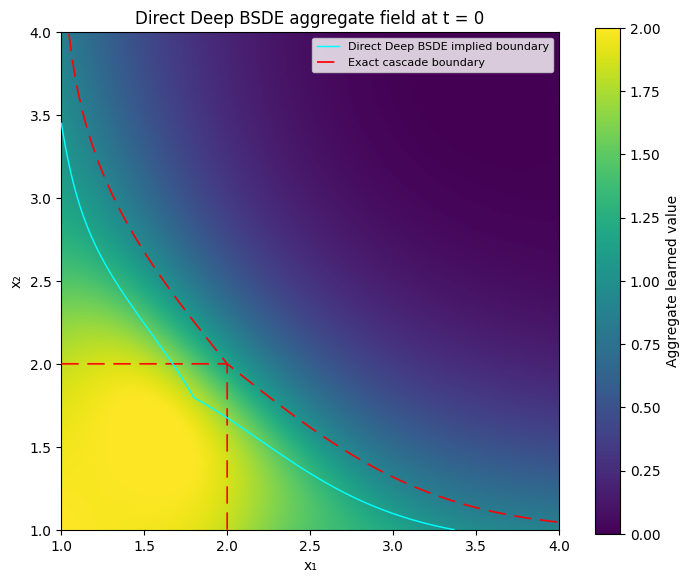

In [15]:
@torch.no_grad()
def naive_surface(
    model: NaiveGlobalFBSDE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    axis = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        CASCADE.model_plot_grid_size,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
    field = model.aggregate_value(points).reshape(
        CASCADE.model_plot_grid_size,
        CASCADE.model_plot_grid_size,
    )
    level_set = torch.minimum(x1, x2) - CASCADE.alpha * field
    return tensor_to_numpy(axis), tensor_to_numpy(field), tensor_to_numpy(level_set)


naive_axis, naive_field, naive_level_set = naive_surface(naive_model)

fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
image = ax.imshow(
    naive_field.T,
    origin="lower",
    extent=[naive_axis[0], naive_axis[-1], naive_axis[0], naive_axis[-1]],
    aspect="equal",
    interpolation="bilinear",
    cmap="viridis",
    vmin=0.0,
    vmax=2.0,
)

contour_exists = (
    np.nanmin(naive_level_set) <= 0.0
    and np.nanmax(naive_level_set) >= 0.0
)
if contour_exists:
    ax.contour(
        naive_axis,
        naive_axis,
        naive_level_set.T,
        levels=[0.0],
        colors=["cyan"],
        linestyles="-",
        linewidths=1.05,
        zorder=6,
    )

plot_exact_boundary(ax, 0.0)
ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
ax.set_aspect("equal")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_title("Direct Deep BSDE aggregate field at t = 0")
fig.colorbar(image, ax=ax, label="Aggregate learned value")

legend_handles = [
    Line2D([0], [0], color="red", linestyle=(0, (10, 5)), linewidth=1.25,
           label="Exact cascade boundary"),
]
if contour_exists:
    legend_handles.insert(
        0,
        Line2D([0], [0], color="cyan", linestyle="-", linewidth=1.05,
               label="Direct Deep BSDE implied boundary"),
    )
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")
save_figure(fig, naive_dir / "direct_deep_bsde_heatmap_t0.pdf")

## 5 Cascade-aware learned-boundary method

The proposed method follows the direction of dependence in the analytical cascade. It first learns the one-particle field, freezes it, uses that frozen field to create the moving two-particle boundary, and then learns the two-particle field inside that learned domain.

### What is changed relative to the direct Deep BSDE baseline

- The one-particle problem is learned first instead of learning the whole system in one global step.
- The singleton training uses first-passage stopping at the known lower-level threshold 2.
- The singleton value is constrained to the natural range from 1 to 2.
- The known singleton boundary value, terminal value, and spatial monotonicity are included in the singleton training objective.
- After singleton training, its parameters are frozen.
- The moving two-particle boundary is generated only from the frozen learned singleton field.
- The level-two exit payoff is also supplied by that same frozen singleton field.
- The level-two network uses the exchange symmetry of the two-particle problem.
- The analytical singleton formula is still hidden from training and is used only afterwards to measure error.

This removes the circular feature of the direct approach: the level-two network cannot move its own boundary while it is being trained.

### 5.1 Learn and freeze the singleton field

In [16]:
def singleton_loss(
    *,
    model: BoundedSingletonFBSDE,
    batch: BrownianBatch,
    boundary_time: Tensor,
    terminal_x: Tensor,
    monotone_time: Tensor,
    monotone_x: Tensor,
) -> tuple[Tensor, dict[str, Tensor]]:
    threshold = 2.0 * CASCADE.alpha
    breach = batch.paths[:, :, 0] <= threshold
    stop_index, hit = first_true_index(breach)

    target = torch.where(
        hit,
        torch.full_like(batch.start_time, 2.0),
        torch.full_like(batch.start_time, 1.0),
    )
    stopped_y = forward_singleton(
        model, batch, stop_index
    )
    path_loss = (stopped_y - target).square().mean()

    boundary_prediction = model.value(
        boundary_time,
        torch.full_like(boundary_time, threshold),
    )
    boundary_loss = (
        boundary_prediction - 2.0
    ).square().mean()

    terminal_prediction = model.value(
        CASCADE.terminal_time, terminal_x
    )
    terminal_loss = (
        terminal_prediction - 1.0
    ).square().mean()

    monotone_x = monotone_x.detach().clone().requires_grad_(True)
    monotone_prediction = model.value(
        monotone_time, monotone_x
    )
    derivative = torch.autograd.grad(
        monotone_prediction.sum(),
        monotone_x,
        create_graph=True,
    )[0]
    monotonicity_loss = torch.relu(
        derivative
    ).square().mean()

    total = (
        path_loss
        + boundary_loss
        + terminal_loss
        + 0.25 * monotonicity_loss
    )
    return total, {
        "path": path_loss,
        "boundary": boundary_loss,
        "terminal": terminal_loss,
        "monotonicity": monotonicity_loss,
    }


def sample_singleton_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
) -> tuple[BrownianBatch, Tensor, Tensor, Tensor, Tensor]:
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=1,
        steps=CASCADE.train_steps,
        x_min=CASCADE.singleton_x_min,
        x_max=CASCADE.x_max,
        max_start_time=CASCADE.max_start_time,
        sigma=CASCADE.sigma,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_time = uniform(
        (batch_size,),
        0.0,
        CASCADE.max_start_time,
        generator,
    )
    terminal_x = uniform(
        (batch_size,),
        2.0 * CASCADE.alpha + 0.001,
        CASCADE.x_max,
        generator,
    )

    terminal_bias = torch.rand(
        batch_size,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    ).square()
    monotone_time = (
        CASCADE.max_start_time
        * (1.0 - terminal_bias)
    )
    spatial_bias = torch.rand(
        batch_size,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    ).square()
    monotone_x = (
        2.0 * CASCADE.alpha
        + 0.001
        + (
            CASCADE.x_max
            - 2.0 * CASCADE.alpha
            - 0.001
        ) * spatial_bias
    )

    return (
        batch,
        boundary_time,
        terminal_x,
        monotone_time,
        monotone_x,
    )

In [17]:
singleton_dir = RESULTS_DIR / "04_cascade_singleton"
seed_everything(SEED + 500)

singleton_model = BoundedSingletonFBSDE(
    x_min=2.0 * CASCADE.alpha,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

singleton_train_generator = make_generator(SEED + 501)
singleton_validation_generator = make_generator(SEED + 502)
singleton_validation_data = sample_singleton_training_data(
    batch_size=CASCADE.validation_size,
    generator=singleton_validation_generator,
    antithetic=False,
)


def singleton_train_objective(
    model: nn.Module,
) -> Tensor:
    data = sample_singleton_training_data(
        batch_size=OPTIM.batch_size,
        generator=singleton_train_generator,
        antithetic=True,
    )
    total, _ = singleton_loss(
        model=model,
        batch=data[0],
        boundary_time=data[1],
        terminal_x=data[2],
        monotone_time=data[3],
        monotone_x=data[4],
    )
    return total


def singleton_validation_objective(
    model: nn.Module,
) -> Tensor:
    with torch.enable_grad():
        total, _ = singleton_loss(
            model=model,
            batch=singleton_validation_data[0],
            boundary_time=singleton_validation_data[1],
            terminal_x=singleton_validation_data[2],
            monotone_time=singleton_validation_data[3],
            monotone_x=singleton_validation_data[4],
        )
    return total


singleton_training = load_or_train(
    model=singleton_model,
    name="cascade_singleton",
    output_dir=singleton_dir,
    train_objective=singleton_train_objective,
    validation_objective=singleton_validation_objective,
    iterations=OPTIM.iterations,
    batch_size=OPTIM.batch_size,
    force=FORCE_SINGLETON,
    learning_rate=OPTIM.learning_rate,
    validation_every=OPTIM.validation_every,
    display_every=OPTIM.display_every,
    scheduler_step=OPTIM.scheduler_step,
    scheduler_gamma=OPTIM.scheduler_gamma,
    gradient_clip=OPTIM.gradient_clip,
)

plot_training_history(
    singleton_training,
    "Cascade singleton stopped training",
    singleton_dir / "training_history.pdf",
)

singleton_model.eval()
for parameter in singleton_model.parameters():
    parameter.requires_grad_(False)


@torch.no_grad()
def learned_singleton_value(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    t_tensor = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    t_tensor, x_tensor = torch.broadcast_tensors(
        t_tensor, x
    )
    raw = singleton_model.value(
        t_tensor.reshape(-1),
        x_tensor.reshape(-1),
    ).reshape(x_tensor.shape)

    return torch.where(
        x_tensor <= 2.0 * CASCADE.alpha,
        torch.full_like(raw, 2.0),
        raw,
    )


def learned_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
) -> Tensor:
    return CASCADE.alpha * learned_singleton_value(
        t, survivor
    )


display(pd.DataFrame({
    "diagnostic": [
        "Best iteration",
        "Best validation loss",
        "Runtime in minutes",
    ],
    "value": [
        singleton_training.best_iteration,
        singleton_training.best_validation_loss,
        singleton_training.runtime_seconds / 60.0,
    ],
}))

cascade_singleton                  iteration   200 train 7.177061e-02 val 7.994994e-02
cascade_singleton                  iteration   400 train 6.548971e-02 val 6.868273e-02
cascade_singleton                  iteration   600 train 5.547116e-02 val 5.682116e-02
cascade_singleton                  iteration   800 train 5.960044e-02 val 5.472441e-02
cascade_singleton                  iteration  1000 train 5.600519e-02 val 5.237176e-02
cascade_singleton                  iteration  1200 train 5.128264e-02 val 5.112749e-02
cascade_singleton                  iteration  1400 train 4.589780e-02 val 4.636856e-02
cascade_singleton                  iteration  1600 train 3.931151e-02 val 3.985330e-02
cascade_singleton                  iteration  1800 train 3.107002e-02 val 3.300143e-02
cascade_singleton                  iteration  2000 train 2.673459e-02 val 2.782203e-02
cascade_singleton                  iteration  2200 train 2.441105e-02 val 2.322203e-02
cascade_singleton                  iteratio

,diagnostic,value
0,Best iteration,15000.000000
1,Best validation loss,0.007531
2,Runtime in minutes,12.497172


### 5.2 Moving boundary induced by the learned singleton field

The non-trivial curved part of the boundary is learned through the singleton network. The flat lower-level pieces follow from the known pasting rule once the state is already at or below the singleton threshold.

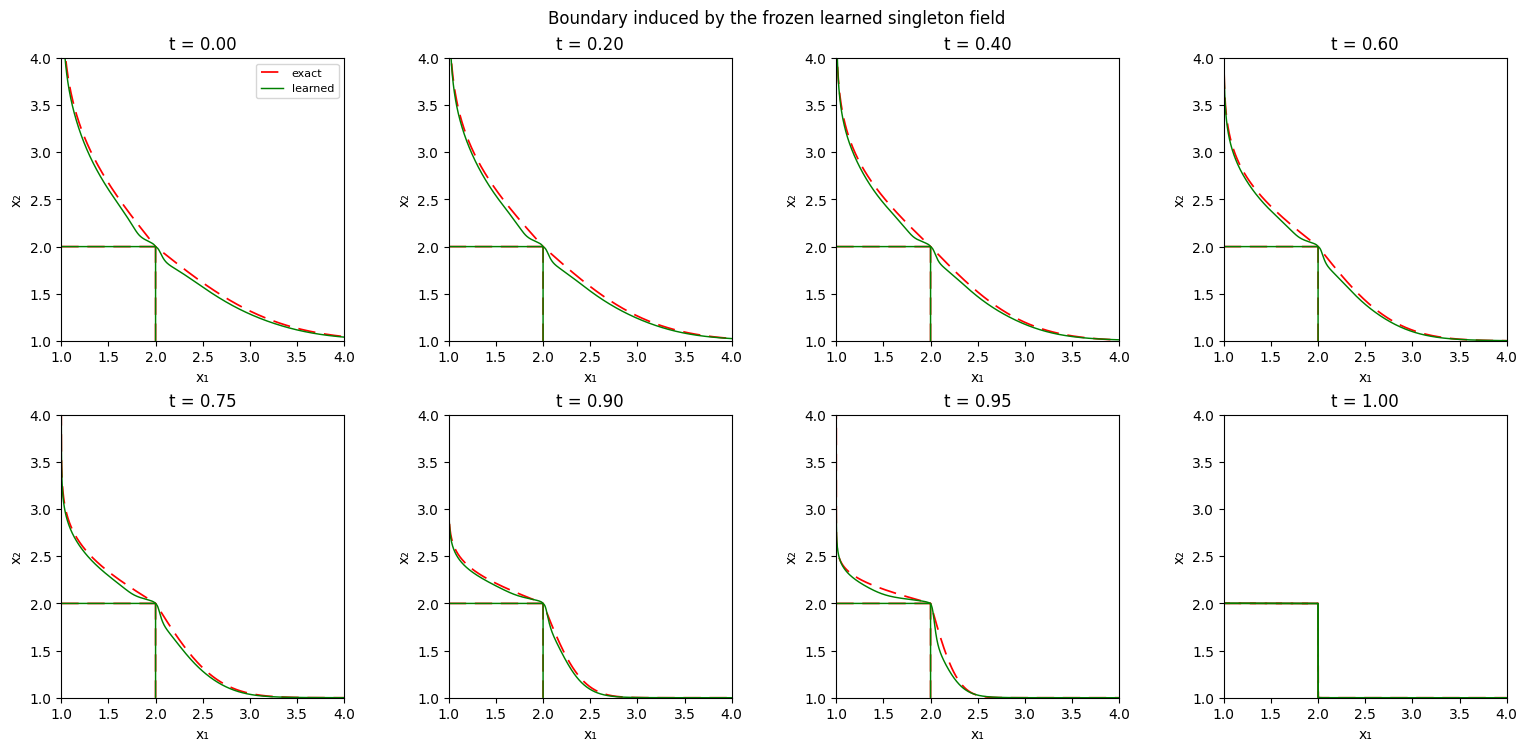

,time,Boundary MAE,Boundary RMSE,Maximum boundary error
0,0.00,0.032559,0.037823,0.078471
1,0.20,0.028522,0.035563,0.078048
2,0.40,0.026016,0.034472,0.077618
3,0.60,0.022018,0.031487,0.079608
4,0.75,0.020004,0.031828,0.088465
5,0.90,0.012745,0.023691,0.069259
6,0.95,0.015438,0.040830,0.166698
7,1.00,0.000313,0.000627,0.007303


In [18]:
fig, axes = plt.subplots(
    2, 4, figsize=(15.5, 7.4), constrained_layout=True
)
survivor = torch.linspace(
    CASCADE.x_min,
    CASCADE.x_max,
    800,
    device=DEVICE,
    dtype=DTYPE,
)
boundary_rows: list[dict[str, float]] = []

for ax, t_value in zip(axes.flat, CASCADE.geometry_times):
    exact = exact_boundary_value(t_value, survivor)
    learned = learned_boundary_value(t_value, survivor)

    ax.plot(
        tensor_to_numpy(exact),
        tensor_to_numpy(survivor),
        color="red",
        linestyle=(0, (10, 5)),
        linewidth=1.25,
        label="exact",
    )
    ax.plot(
        tensor_to_numpy(survivor),
        tensor_to_numpy(exact),
        color="red",
        linestyle=(0, (10, 5)),
        linewidth=1.25,
    )
    ax.plot(
        tensor_to_numpy(learned),
        tensor_to_numpy(survivor),
        color="green",
        linestyle="-",
        linewidth=1.05,
        label="learned",
    )
    ax.plot(
        tensor_to_numpy(survivor),
        tensor_to_numpy(learned),
        color="green",
        linestyle="-",
        linewidth=1.05,
    )

    ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
    ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"t = {t_value:.2f}")

    mask = survivor > 2.0 * CASCADE.alpha
    error = learned[mask] - exact[mask]
    boundary_rows.append({
        "time": float(t_value),
        "Boundary MAE": float(error.abs().mean().cpu()),
        "Boundary RMSE": float(torch.sqrt(error.square().mean()).cpu()),
        "Maximum boundary error": float(error.abs().max().cpu()),
    })

axes.flat[0].legend(fontsize=8)
fig.suptitle("Boundary induced by the frozen learned singleton field")
save_figure(fig, singleton_dir / "learned_boundary_eight_times.pdf")

singleton_boundary_metrics = pd.DataFrame(boundary_rows)
singleton_boundary_metrics.to_csv(
    singleton_dir / "boundary_metrics.csv", index=False
)
display(singleton_boundary_metrics.round(6))

### 5.3 Learn the two-particle field inside the frozen learned domain

The singleton network remains frozen throughout this stage. The two-particle paths are stopped at the learned moving boundary and the frozen singleton value supplies the exit target.

In [19]:
cascade_dir = RESULTS_DIR / "05_cascade_level_two"
seed_everything(SEED + 600)

cascade_model = SymmetricTwoParticleFBSDE(
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    width=CASCADE.width,
    depth=CASCADE.depth,
).to(DEVICE)

learned_boundary_provider = (
    lambda t, r: learned_boundary_value(t, r)
)
learned_lower_value_provider = (
    lambda t, r: learned_singleton_value(t, r)
)

cascade_train_generator = make_generator(SEED + 601)
cascade_validation_generator = make_generator(SEED + 602)
cascade_validation_data = sample_n2_training_data(
    batch_size=CASCADE.validation_size,
    generator=cascade_validation_generator,
    antithetic=False,
)


def learned_terminal_continuation_mask(
    points: Tensor,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    threshold = learned_boundary_value(
        torch.ones_like(larger), larger
    )
    return smaller > threshold


def cascade_train_objective(
    model: nn.Module,
) -> Tensor:
    data = sample_n2_training_data(
        batch_size=OPTIM.batch_size,
        generator=cascade_train_generator,
        antithetic=True,
    )
    total, _ = n2_loss(
        model=model,
        batch=data[0],
        boundary_provider=learned_boundary_provider,
        lower_value_provider=learned_lower_value_provider,
        terminal_value=0.0,
        pasting_time=data[1],
        survivor=data[2],
        terminal_points=data[3],
        terminal_mask_function=learned_terminal_continuation_mask,
    )
    return total


def cascade_validation_objective(
    model: nn.Module,
) -> Tensor:
    total, _ = n2_loss(
        model=model,
        batch=cascade_validation_data[0],
        boundary_provider=learned_boundary_provider,
        lower_value_provider=learned_lower_value_provider,
        terminal_value=0.0,
        pasting_time=cascade_validation_data[1],
        survivor=cascade_validation_data[2],
        terminal_points=cascade_validation_data[3],
        terminal_mask_function=learned_terminal_continuation_mask,
    )
    return total


cascade_training = load_or_train(
    model=cascade_model,
    name="cascade_level_two",
    output_dir=cascade_dir,
    train_objective=cascade_train_objective,
    validation_objective=cascade_validation_objective,
    iterations=OPTIM.iterations,
    batch_size=OPTIM.batch_size,
    force=FORCE_CASCADE_LEVEL_TWO,
    learning_rate=OPTIM.learning_rate,
    validation_every=OPTIM.validation_every,
    display_every=OPTIM.display_every,
    scheduler_step=OPTIM.scheduler_step,
    scheduler_gamma=OPTIM.scheduler_gamma,
    gradient_clip=OPTIM.gradient_clip,
)
cascade_model.eval()

plot_training_history(
    cascade_training,
    "Cascade-aware level-two training",
    cascade_dir / "training_history.pdf",
)

display(pd.DataFrame({
    "diagnostic": [
        "Best iteration",
        "Best validation loss",
        "Runtime in minutes",
    ],
    "value": [
        cascade_training.best_iteration,
        cascade_training.best_validation_loss,
        cascade_training.runtime_seconds / 60.0,
    ],
}))

cascade_level_two                  iteration   200 train 4.478308e-01 val 4.810503e-01
cascade_level_two                  iteration   400 train 4.290715e-01 val 4.403383e-01
cascade_level_two                  iteration   600 train 3.312855e-01 val 3.454791e-01
cascade_level_two                  iteration   800 train 2.584573e-01 val 2.718060e-01
cascade_level_two                  iteration  1000 train 2.536026e-01 val 2.595823e-01
cascade_level_two                  iteration  1200 train 2.420925e-01 val 2.472250e-01
cascade_level_two                  iteration  1400 train 2.316663e-01 val 2.423188e-01
cascade_level_two                  iteration  1600 train 2.532805e-01 val 2.362043e-01
cascade_level_two                  iteration  1800 train 2.315183e-01 val 2.316947e-01
cascade_level_two                  iteration  2000 train 2.029010e-01 val 2.293806e-01
cascade_level_two                  iteration  2200 train 2.125841e-01 val 2.212828e-01
cascade_level_two                  iteratio

,diagnostic,value
0,Best iteration,15000.000000
1,Best validation loss,0.027527
2,Runtime in minutes,21.003603


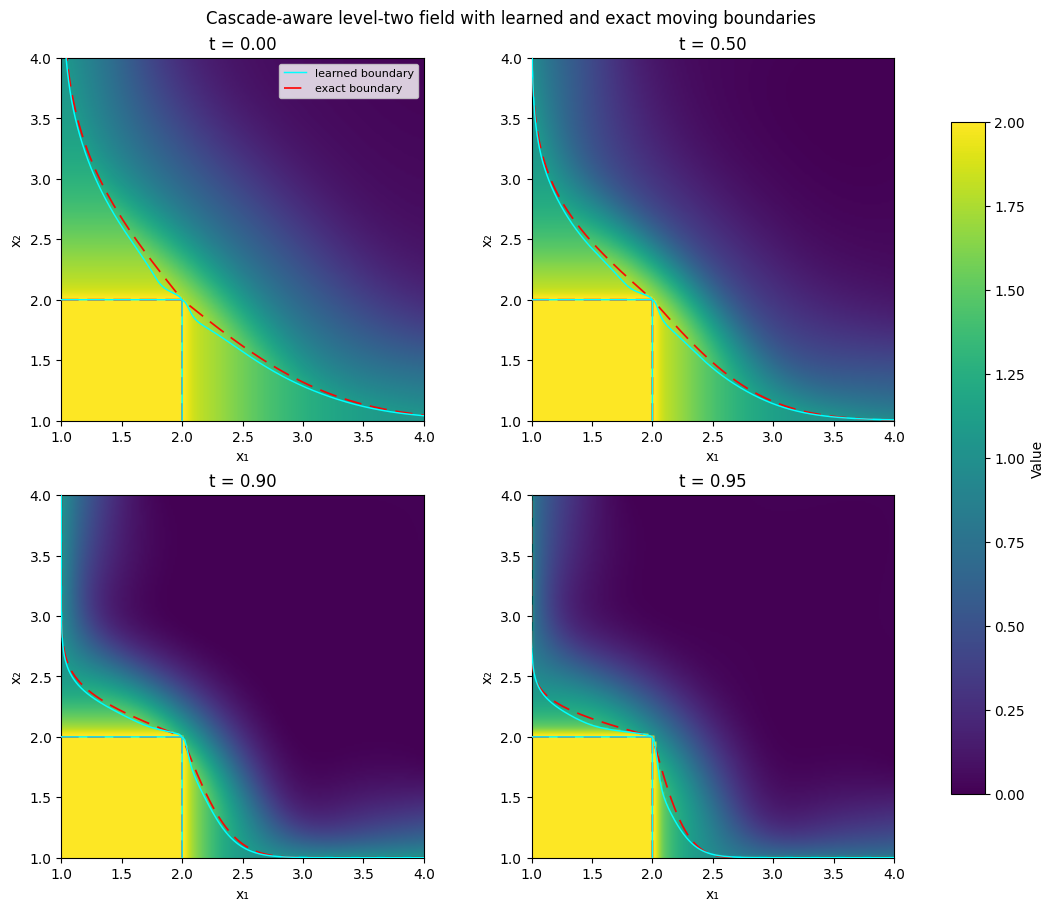

In [20]:
cascade_surfaces = {
    float(t_value): model_surface(
        model=cascade_model,
        time_value=float(t_value),
        boundary_provider=learned_boundary_provider,
        lower_value_provider=learned_lower_value_provider,
        terminal_value=0.0,
    )
    for t_value in CASCADE.comparison_times
}


def cascade_boundary_plotter(
    ax: plt.Axes, t_value: float
) -> None:
    plot_graph_boundary(
        ax,
        t_value,
        learned_boundary_value,
        color="cyan",
        linestyle="-",
        linewidth=1.05,
        label="learned boundary",
    )
    plot_exact_boundary(
        ax,
        t_value,
        label="exact boundary",
    )


plot_four_heatmaps(
    surfaces=cascade_surfaces,
    title="Cascade-aware level-two field with learned and exact moving boundaries",
    output_path=cascade_dir / "cascade_field_four_times.pdf",
    boundary_plotter=cascade_boundary_plotter,
)

## 6 Independent comparison

All exact quantities in this section are used only after training. The direct Deep BSDE model is evaluated at time zero because its value network is trained as an initial-time map. The oracle and cascade-aware fields are also shown at later times.

Field errors are reported only inside the exact continuation region. Region accuracy compares the learned continuation classification with the exact one. Range diagnostics are reported on the full plotting grid. Boundary distances are symmetric point-cloud distances between the candidate and exact curves.

In [21]:
@torch.no_grad()
def exact_boundary_point_cloud(time_value: float) -> np.ndarray:
    curves = exact_boundary_curves(time_value)
    return np.concatenate(
        [np.column_stack((x_curve, y_curve))
         for x_curve, y_curve in curves],
        axis=0,
    )


@torch.no_grad()
def graph_boundary_point_cloud(
    time_value: float,
    boundary_function: Callable[[float, Tensor], Tensor],
) -> np.ndarray:
    survivor = torch.linspace(
        CASCADE.x_min,
        CASCADE.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = boundary_function(time_value, survivor)
    points = torch.cat(
        (
            torch.stack((boundary, survivor), dim=1),
            torch.stack((survivor, boundary), dim=1),
        ),
        dim=0,
    )
    inside_box = (
        (points[:, 0] >= CASCADE.x_min)
        & (points[:, 0] <= CASCADE.x_max)
        & (points[:, 1] >= CASCADE.x_min)
        & (points[:, 1] <= CASCADE.x_max)
    )
    return tensor_to_numpy(points[inside_box])


def implicit_boundary_point_cloud(
    axis: np.ndarray,
    level_set: np.ndarray,
) -> np.ndarray:
    points: list[np.ndarray] = []
    horizontal = level_set[:-1, :] * level_set[1:, :] <= 0.0
    i, j = np.where(horizontal)
    if i.size:
        points.append(np.column_stack((
            0.5 * (axis[i] + axis[i + 1]), axis[j]
        )))
    vertical = level_set[:, :-1] * level_set[:, 1:] <= 0.0
    i, j = np.where(vertical)
    if i.size:
        points.append(np.column_stack((
            axis[i], 0.5 * (axis[j] + axis[j + 1])
        )))
    if not points:
        return np.empty((0, 2))
    return np.concatenate(points, axis=0)


def point_cloud_metrics(
    candidate: np.ndarray,
    exact: np.ndarray,
) -> dict[str, float]:
    if candidate.shape[0] == 0:
        return {
            "Boundary mean distance": math.nan,
            "Boundary RMSE": math.nan,
            "Boundary Hausdorff distance": math.nan,
        }
    candidate_tree = cKDTree(candidate)
    exact_tree = cKDTree(exact)
    exact_to_candidate = candidate_tree.query(exact, k=1)[0]
    candidate_to_exact = exact_tree.query(candidate, k=1)[0]
    combined = np.concatenate((exact_to_candidate, candidate_to_exact))
    return {
        "Boundary mean distance": float(combined.mean()),
        "Boundary RMSE": float(np.sqrt(np.mean(combined**2))),
        "Boundary Hausdorff distance": float(combined.max()),
    }


@torch.no_grad()
def completed_oracle_field(t_value: float, points: Tensor) -> Tensor:
    return completed_n2_value(
        model=oracle_model,
        t=t_value,
        points=points,
        boundary_provider=exact_boundary_provider,
        lower_value_provider=exact_lower_value_provider,
        terminal_value=0.0,
    )


@torch.no_grad()
def completed_cascade_field(t_value: float, points: Tensor) -> Tensor:
    return completed_n2_value(
        model=cascade_model,
        t=t_value,
        points=points,
        boundary_provider=learned_boundary_provider,
        lower_value_provider=learned_lower_value_provider,
        terminal_value=0.0,
    )


field_rows: list[dict[str, float | int | str]] = []
for t_value in CASCADE.comparison_times:
    reference = reference_surfaces[float(t_value)]
    points = reference["points"].to(DEVICE)
    exact_field = reference["field"].to(DEVICE)
    exact_inside = reference["inside"].to(DEVICE)

    for method, prediction, predicted_inside in (
        (
            "oracle",
            completed_oracle_field(float(t_value), points),
            exact_inside,
        ),
        (
            "cascade-aware",
            completed_cascade_field(float(t_value), points),
            points.min(dim=1).values
            > learned_boundary_value(
                float(t_value), points.max(dim=1).values
            ),
        ),
    ):
        error = prediction[exact_inside] - exact_field[exact_inside]
        field_rows.append({
            "method": method,
            "seed": math.nan,
            "time": float(t_value),
            "Continuation field MAE": float(error.abs().mean().cpu()),
            "Continuation field RMSE": float(torch.sqrt(error.square().mean()).cpu()),
            "Maximum continuation field error": float(error.abs().max().cpu()),
            "Region accuracy": float(
                (predicted_inside == exact_inside).to(DTYPE).mean().cpu()
            ),
            "Field minimum": float(prediction.min().cpu()),
            "Field maximum": float(prediction.max().cpu()),
            "Range violation rate": float(
                ((prediction < 0.0) | (prediction > 2.0))
                .to(DTYPE).mean().cpu()
            ),
        })

reference = reference_surfaces[0.0]
points = reference["points"].to(DEVICE)
exact_field = reference["field"].to(DEVICE)
exact_inside = reference["inside"].to(DEVICE)
prediction = naive_model.aggregate_value(points).detach()
predicted_inside = points.min(dim=1).values > CASCADE.alpha * prediction
error = prediction[exact_inside] - exact_field[exact_inside]
field_rows.append({
    "method": "direct Deep BSDE",
    "seed": OPTIM.naive_seed,
    "time": 0.0,
    "Continuation field MAE": float(error.abs().mean().cpu()),
    "Continuation field RMSE": float(torch.sqrt(error.square().mean()).cpu()),
    "Maximum continuation field error": float(error.abs().max().cpu()),
    "Region accuracy": float(
        (predicted_inside == exact_inside).to(DTYPE).mean().cpu()
    ),
    "Field minimum": float(prediction.min().cpu()),
    "Field maximum": float(prediction.max().cpu()),
    "Range violation rate": float(
        ((prediction < 0.0) | (prediction > 2.0))
        .to(DTYPE).mean().cpu()
    ),
})

field_metrics = pd.DataFrame(field_rows)
field_metrics.to_csv(
    RESULTS_DIR / "06_field_and_region_metrics.csv", index=False
)
display(field_metrics.round(6))

boundary_rows: list[dict[str, float | int | str]] = []
exact_t0_points = exact_boundary_point_cloud(0.0)
candidate = implicit_boundary_point_cloud(naive_axis, naive_level_set)
boundary_rows.append({
    "method": "direct Deep BSDE",
    "seed": OPTIM.naive_seed,
    "time": 0.0,
    "Boundary point count": candidate.shape[0],
    **point_cloud_metrics(candidate, exact_t0_points),
})

for t_value in CASCADE.comparison_times:
    exact_points = exact_boundary_point_cloud(float(t_value))
    candidate = graph_boundary_point_cloud(
        float(t_value), learned_boundary_value
    )
    boundary_rows.append({
        "method": "cascade-aware",
        "seed": math.nan,
        "time": float(t_value),
        "Boundary point count": candidate.shape[0],
        **point_cloud_metrics(candidate, exact_points),
    })

boundary_metrics = pd.DataFrame(boundary_rows)
boundary_metrics.to_csv(
    RESULTS_DIR / "06_boundary_metrics.csv", index=False
)
display(boundary_metrics.round(6))

,method,seed,time,Continuation field MAE,Continuation field RMSE,Maximum continuation field error,Region accuracy,Field minimum,Field maximum,Range violation rate
0,oracle,NaN,0.00,0.023280,0.029947,0.086530,1.000000,0.000723,2.000000,0.000000
1,cascade-aware,NaN,0.00,0.066216,0.076126,0.167438,0.986025,0.019972,2.000000,0.000000
2,oracle,NaN,0.50,0.022632,0.034713,0.128109,1.000000,-0.000380,2.000000,0.002150
3,cascade-aware,NaN,0.50,0.036968,0.053879,0.149508,0.990863,-0.005142,2.000000,0.040312
4,oracle,NaN,0.90,0.051109,0.099854,0.470847,1.000000,-0.011773,2.000000,0.224940
5,cascade-aware,NaN,0.90,0.046760,0.092691,0.419052,0.994088,-0.010945,2.000000,0.280032
6,oracle,NaN,0.95,0.078079,0.163843,0.730437,1.000000,-0.006846,2.000000,0.135716
7,cascade-aware,NaN,0.95,0.080045,0.149331,0.617995,0.992475,-0.012029,2.000000,0.102661
8,direct Deep BSDE,123.0,0.00,0.268410,0.322585,0.761473,0.901371,-0.000002,2.037995,0.023112


,method,seed,time,Boundary point count,Boundary mean distance,Boundary RMSE,Boundary Hausdorff distance
0,direct Deep BSDE,123.0,0.00,291,0.232751,0.258779,0.626654
1,cascade-aware,NaN,0.00,1600,0.018521,0.025608,0.061635
2,cascade-aware,NaN,0.50,1600,0.012371,0.019638,0.051829
3,cascade-aware,NaN,0.90,1600,0.004848,0.010149,0.027468
4,cascade-aware,NaN,0.95,1600,0.004207,0.011719,0.051330


In [22]:
@torch.no_grad()
def prescribed_exit_indices(
    batch: BrownianBatch,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
) -> tuple[Tensor, Tensor]:
    smaller = batch.paths.min(dim=2).values
    larger = batch.paths.max(dim=2).values
    threshold = boundary_provider(batch.times, larger)
    return first_true_index(smaller <= threshold)


@torch.no_grad()
def pasting_mae(
    *,
    model: SymmetricTwoParticleFBSDE,
    boundary_provider: Callable[[Tensor, Tensor], Tensor],
    lower_value_provider: Callable[[Tensor, Tensor], Tensor],
    seed: int,
) -> float:
    generator = make_generator(seed)
    n = CASCADE.diagnostic_paths
    t = uniform((n,), 0.0, CASCADE.max_start_time, generator)
    survivor = uniform((n,), 2.001, CASCADE.x_max, generator)
    threshold = boundary_provider(t, survivor)
    target = lower_value_provider(t, survivor)
    points = torch.stack((threshold, survivor), dim=1)
    prediction = model.value(t, points)
    return float((prediction - target).abs().mean().cpu())


diagnostic_generator = make_generator(SEED + 700)
diagnostic_batch = sample_brownian_batch(
    batch_size=CASCADE.diagnostic_paths,
    dimension=2,
    steps=CASCADE.diagnostic_steps,
    x_min=CASCADE.x_min,
    x_max=CASCADE.x_max,
    max_start_time=0.0,
    sigma=CASCADE.sigma,
    generator=diagnostic_generator,
    antithetic=False,
)

exact_index, exact_hit = prescribed_exit_indices(
    diagnostic_batch, exact_boundary_provider
)
cascade_index, cascade_hit = prescribed_exit_indices(
    diagnostic_batch, learned_boundary_provider
)
dt = CASCADE.terminal_time / CASCADE.diagnostic_steps


def exit_comparison_row(
    method: str,
    seed: float,
    index: Tensor,
    hit: Tensor,
) -> dict[str, float | str]:
    both_hit = exact_hit & hit
    conditional_rmse = (
        float(
            torch.sqrt(
                (exact_index[both_hit].to(DTYPE)
                 - index[both_hit].to(DTYPE)).square().mean()
            ).cpu() * dt
        )
        if bool(both_hit.any())
        else math.nan
    )
    return {
        "method": method,
        "seed": seed,
        "Exit occurrence agreement": float(
            (exact_hit == hit).to(DTYPE).mean().cpu()
        ),
        "Censored exit-time MAE": float(
            (exact_index.to(DTYPE) - index.to(DTYPE))
            .abs().mean().cpu() * dt
        ),
        "Both-hit exit-time RMSE": conditional_rmse,
        "Both-hit fraction": float(both_hit.to(DTYPE).mean().cpu()),
    }


exit_rows = [
    exit_comparison_row(
        "cascade-aware", math.nan, cascade_index, cascade_hit
    )
]
rollout = naive_global_rollout(naive_model, diagnostic_batch)
exit_rows.append(exit_comparison_row(
    "direct Deep BSDE",
    float(OPTIM.naive_seed),
    rollout["first_exit_index"],
    rollout["first_exit_hit"],
))

exit_metrics = pd.DataFrame(exit_rows)
exit_metrics.to_csv(
    RESULTS_DIR / "06_exit_metrics.csv", index=False
)
display(exit_metrics.round(6))

pasting_metrics = pd.DataFrame([
    {
        "method": "oracle",
        "Pasting MAE": pasting_mae(
            model=oracle_model,
            boundary_provider=exact_boundary_provider,
            lower_value_provider=exact_lower_value_provider,
            seed=SEED + 701,
        ),
    },
    {
        "method": "cascade-aware",
        "Pasting MAE": pasting_mae(
            model=cascade_model,
            boundary_provider=learned_boundary_provider,
            lower_value_provider=learned_lower_value_provider,
            seed=SEED + 702,
        ),
    },
])
pasting_metrics.to_csv(
    RESULTS_DIR / "06_pasting_metrics.csv", index=False
)
display(pasting_metrics.round(6))

,method,seed,Exit occurrence agreement,Censored exit-time MAE,Both-hit exit-time RMSE,Both-hit fraction
0,cascade-aware,NaN,0.99185,0.010517,0.046575,0.57780
1,direct Deep BSDE,123.0,0.87810,0.106331,0.151465,0.46405


,method,Pasting MAE
0,oracle,0.023463
1,cascade-aware,0.034253


### 6.1 Thesis heatmap comparison at time zero

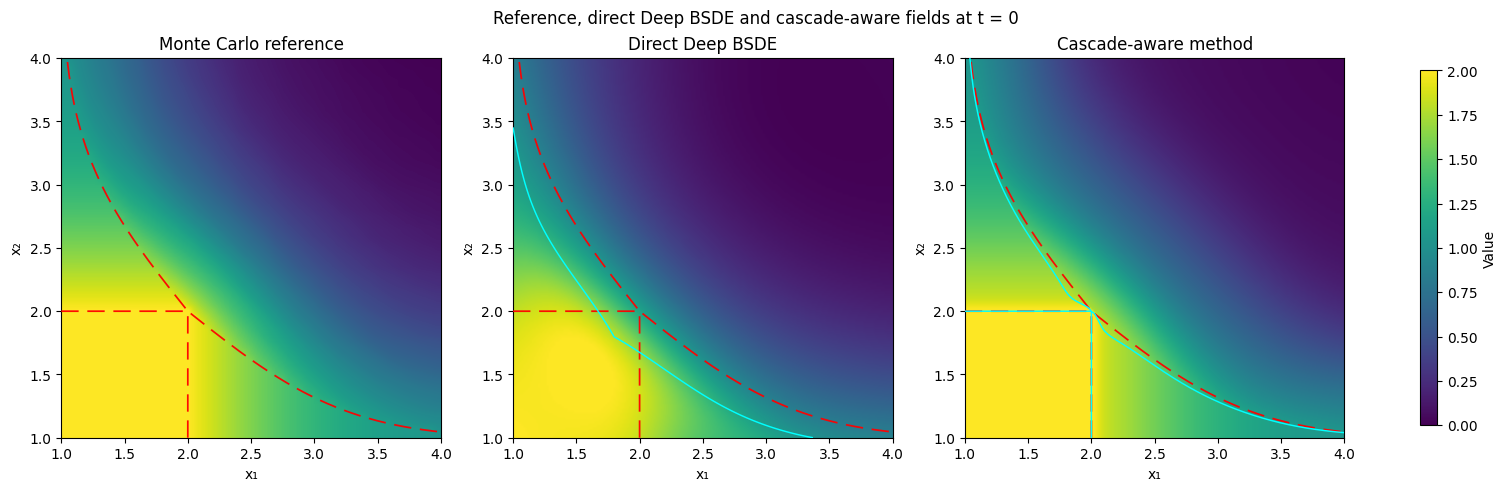

In [23]:
reference = reference_surfaces[0.0]
reference_axis = tensor_to_numpy(reference["axis"])
reference_field = tensor_to_numpy(reference["field"]).reshape(
    CASCADE.reference_grid_size,
    CASCADE.reference_grid_size,
)
cascade_axis, cascade_field = cascade_surfaces[0.0]

fig, axes = plt.subplots(
    1, 3, figsize=(15.0, 4.8), constrained_layout=True
)
image = None
panels = (
    (axes[0], reference_axis, reference_field, "Monte Carlo reference"),
    (axes[1], naive_axis, naive_field, "Direct Deep BSDE"),
    (axes[2], cascade_axis, cascade_field, "Cascade-aware method"),
)
for ax, axis_np, field, title in panels:
    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]],
        aspect="equal",
        interpolation="bilinear",
        cmap="viridis",
        vmin=0.0,
        vmax=2.0,
    )
    plot_exact_boundary(ax, 0.0)
    ax.set_xlim(CASCADE.x_min, CASCADE.x_max)
    ax.set_ylim(CASCADE.x_min, CASCADE.x_max)
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(title)

if (
    np.nanmin(naive_level_set) <= 0.0
    and np.nanmax(naive_level_set) >= 0.0
):
    axes[1].contour(
        naive_axis,
        naive_axis,
        naive_level_set.T,
        levels=[0.0],
        colors=["cyan"],
        linestyles="-",
        linewidths=1.05,
        zorder=6,
    )

plot_graph_boundary(
    axes[2],
    0.0,
    learned_boundary_value,
    color="cyan",
    linestyle="-",
    linewidth=1.05,
)

if image is None:
    raise RuntimeError("No comparison heatmap was created")
fig.colorbar(image, ax=axes, shrink=0.88, label="Value")
fig.suptitle("Reference, direct Deep BSDE and cascade-aware fields at t = 0")
save_figure(
    fig,
    RESULTS_DIR / "06_thesis_heatmap_comparison_t0.pdf",
)

## 7 Higher-dimensional extension

No three-particle numerical experiment is included in this notebook.

The cascade-aware idea extends recursively. Once a lower-level field has been trained, freeze it. Use that frozen field to define the next moving boundary and the value supplied at first exit. Train the next field, freeze it, and repeat.

For a symmetric system, the same procedure can be applied level by level as the number of surviving particles increases. The boundary becomes a moving hypersurface rather than a curve, but the direction of dependence is unchanged. The method is structurally extensible, although the computational cost still increases with dimension.

## 8 Saved outputs and interpretation

All checkpoints, figures and metric tables are saved under the folder `dissertation_moving_boundary_final_results`.

Main thesis figures produced by the notebook

- `01_reference/reference_field_eight_times.pdf`
- `02_oracle/oracle_field_four_times.pdf`
- `03_direct_deep_bsde/direct_deep_bsde_heatmap_t0.pdf`
- `04_cascade_singleton/learned_boundary_eight_times.pdf`
- `05_cascade_level_two/cascade_field_four_times.pdf`
- `06_thesis_heatmap_comparison_t0.pdf`

Main numerical tables

- reference Monte Carlo uncertainty
- direct Deep BSDE summary
- learned singleton boundary errors
- field and continuation-region errors
- moving-boundary distance errors
- exit-time diagnostics
- boundary-pasting diagnostics

The intended comparison is simple. The oracle asks whether the level-two network works when the exact boundary is supplied. The direct Deep BSDE baseline asks what happens when the full endogenous problem is attacked in one step. The cascade-aware method asks whether learning and freezing the lower level first gives a more accurate moving boundary and, in turn, a more accurate two-particle field.